<a href="https://colab.research.google.com/github/adriennie/paged-kv/blob/main/vllm_vs_hf_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install vllm transformers torch pandas matplotlib seaborn

In [4]:
import os
import sys

# 1. Force vLLM to use Engine V0 (stable for single GPU / T4)
os.environ["VLLM_USE_V1"] = "0"

# 2. Patch Jupyter/Colab ipykernel stdout issue
if not hasattr(sys.stdout, "fileno"):
    sys.stdout.fileno = lambda: 1

In [5]:

import time
import torch
import pandas as pd
from vllm import LLM, SamplingParams

# --- CONFIGURATION ---
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
BATCH_SIZES = [1, 2, 4, 8, 16, 32]
MAX_NEW_TOKENS = 128
GPU_UTILIZATION = 0.80  # Slightly lower to give T4 safety room

VARIABLE_PROMPTS = [
    "What is key-value caching in LLMs?",
    "Explain recursion in Python briefly.",
    "Compare monolithic and microservice software architectures in terms of scalability, operational complexity, and deployment independence.",
    "Explain how database indexes improve SELECT query performance, and discuss the trade-offs regarding INSERT and UPDATE operations.",
    (
        "Virtual memory is a fundamental abstraction in modern operating systems that decouples logical address space from physical DRAM. "
        "By dividing memory into fixed-size pages and using page tables managed by the MMU, OS kernels can eliminate external fragmentation, "
        "enforce process isolation, and dynamically map virtual pages to non-contiguous physical DRAM frames. "
        "In the context of autoregressive Large Language Model serving, explain how PagedAttention adapts this virtual memory paging principle "
        "to manage Key-Value (KV) cache tensors, and compare its block allocation mechanism against traditional contiguous tensor allocation."
    ),
    (
        "Autoregressive language models generate text sequentially, predicting one token at a time based on preceding context vectors. "
        "Because model parameters must be re-read from GPU HBM to SRAM for every single generated token, token generation is memory-bandwidth bound. "
        "Detail how storing Key and Value states in a KV cache avoids redundant matrix-matrix multiplications during decode steps, "
        "and analyze why dynamic output sequence lengths cause severe internal and external memory fragmentation in static allocation engines."
    )
]

def get_batch_prompts(target_bs):
    multiplier = (target_bs // len(VARIABLE_PROMPTS)) + 1
    return (VARIABLE_PROMPTS * multiplier)[:target_bs]

In [7]:
import os
import sys

# 1. Disable V1 engine BEFORE importing vllm (forces legacy V0 engine)
os.environ["VLLM_USE_V1"] = "0"
os.environ["VLLM_LOGGING_LEVEL"] = "ERROR"

# 2. Patch sys.stdout and sys.stderr with real file descriptors
try:
    sys.stdout.fileno = lambda: 1
    sys.stderr.fileno = lambda: 2
except Exception:
    pass

import time
import torch
import pandas as pd
from vllm import LLM, SamplingParams

# --- CONFIGURATION ---
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
BATCH_SIZES = [1, 2, 4, 8, 16, 32]
MAX_NEW_TOKENS = 128
GPU_UTILIZATION = 0.80

VARIABLE_PROMPTS = [
    "What is key-value caching in LLMs?",
    "Explain recursion in Python briefly.",
    "Compare monolithic and microservice software architectures in terms of scalability, operational complexity, and deployment independence.",
    "Explain how database indexes improve SELECT query performance, and discuss the trade-offs regarding INSERT and UPDATE operations.",
    (
        "Virtual memory is a fundamental abstraction in modern operating systems that decouples logical address space from physical DRAM. "
        "By dividing memory into fixed-size pages and using page tables managed by the MMU, OS kernels can eliminate external fragmentation, "
        "enforce process isolation, and dynamically map virtual pages to non-contiguous physical DRAM frames. "
        "In the context of autoregressive Large Language Model serving, explain how PagedAttention adapts this virtual memory paging principle "
        "to manage Key-Value (KV) cache tensors, and compare its block allocation mechanism against traditional contiguous tensor allocation."
    ),
    (
        "Autoregressive language models generate text sequentially, predicting one token at a time based on preceding context vectors. "
        "Because model parameters must be re-read from GPU HBM to SRAM for every single generated token, token generation is memory-bandwidth bound. "
        "Detail how storing Key and Value states in a KV cache avoids redundant matrix-matrix multiplications during decode steps, "
        "and analyze why dynamic output sequence lengths cause severe internal and external memory fragmentation in static allocation engines."
    )
]

def get_batch_prompts(target_bs):
    multiplier = (target_bs // len(VARIABLE_PROMPTS)) + 1
    return (VARIABLE_PROMPTS * multiplier)[:target_bs]

# --- INITIALIZE VLLM ENGINE ---
print("=== Initializing vLLM Engine ===")

vllm_engine = LLM(
    model=MODEL_ID,
    gpu_memory_utilization=GPU_UTILIZATION,
    max_model_len=2048,
    block_size=16,
    enforce_eager=True,
    dtype="float16"
)

sampling_params = SamplingParams(temperature=0.0, max_tokens=MAX_NEW_TOKENS)

torch.cuda.synchronize()
vllm_base_memory_gb = torch.cuda.memory_allocated() / (1024 ** 3)

# --- WARMUP PASS ---
print("Executing vLLM Warmup...")
_ = vllm_engine.generate(get_batch_prompts(2), sampling_params)
torch.cuda.synchronize()

# --- BENCHMARK LOOP ---
vllm_results = []
print("\n=== Running vLLM Benchmark Loop ===")

for bs in BATCH_SIZES:
    prompts = get_batch_prompts(bs)

    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    start_time = time.perf_counter()

    outputs = vllm_engine.generate(prompts, sampling_params)

    torch.cuda.synchronize()
    elapsed_time = time.perf_counter() - start_time

    peak_allocated_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
    peak_reserved_gb = torch.cuda.max_memory_reserved() / (1024 ** 3)

    total_generated_tokens = sum([len(out.outputs[0].token_ids) for out in outputs])

    throughput = total_generated_tokens / elapsed_time
    req_per_sec = bs / elapsed_time
    sec_per_token_per_req = elapsed_time / (total_generated_tokens / bs) if total_generated_tokens > 0 else 0

    vllm_results.append({
        "Engine": "vLLM (PagedAttention)",
        "Batch Size": bs,
        "Total Time (s)": round(elapsed_time, 3),
        "Total Generated Tokens": total_generated_tokens,
        "Throughput (tok/s)": round(throughput, 2),
        "Request Rate (req/s)": round(req_per_sec, 2),
        "Agg Sec/Tok/Req": round(sec_per_token_per_req, 4),
        "Base VRAM (GB)": round(vllm_base_memory_gb, 2),
        "Peak Allocated VRAM (GB)": round(peak_allocated_gb, 2),
        "Peak Reserved VRAM (GB)": round(peak_reserved_gb, 2),
        "Incremental VRAM (GB)": round(max(0.0, peak_allocated_gb - vllm_base_memory_gb), 2)
    })
    print(f"[vLLM] BS: {bs:2d} | Tokens: {total_generated_tokens:4d} | Throughput: {throughput:6.2f} tok/s | Peak VRAM: {peak_allocated_gb:.2f} GB | Time: {elapsed_time:.2f}s")

# Save results
df_vllm = pd.DataFrame(vllm_results)
df_vllm.to_csv("vllm_results.csv", index=False)
display(df_vllm)

=== Initializing vLLM Engine ===
(EngineCore pid=4557) ERROR 10-09 13:21:28 [fa_utils.py:212] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


Executing vLLM Warmup...


Rendering prompts:   0%|          | 0/2 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 2/2 [00:10<00:00,  5.10s/it, est. speed input: 1.67 toks/s, output: 25.12 toks/s]

...

[vLLM] BS: 16 | Tokens: 2048 | Throughput: 270.61 tok/s | Peak VRAM: 0.00 GB | Time: 7.57s


Rendering prompts:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 32/32 [00:04<00:00,  6.95it/s, est. speed input: 283.81 toks/s, output: 889.41 toks/s]

[vLLM] BS: 32 | Tokens: 4096 | Throughput: 877.69 tok/s | Peak VRAM: 0.00 GB | Time: 4.67s


,Engine,Batch Size,Total Time (s),Total Generated Tokens,Throughput (tok/s),Request Rate (req/s),Agg Sec/Tok/Req,Base VRAM (GB),Peak Allocated VRAM (GB),Peak Reserved VRAM (GB),Incremental VRAM (GB)
0,vLLM (PagedAttention),1,4.259,128,30.05,0.23,0.0333,0.0,0.0,0.0,0.0
1,vLLM (PagedAttention),2,5.107,256,50.13,0.39,0.0399,0.0,0.0,0.0,0.0
2,vLLM (PagedAttention),4,4.411,512,116.06,0.91,0.0345,0.0,0.0,0.0,0.0
3,vLLM (PagedAttention),8,4.511,1024,226.98,1.77,0.0352,0.0,0.0,0.0,0.0
4,vLLM (PagedAttention),16,7.568,2048,270.61,2.11,0.0591,0.0,0.0,0.0,0.0
5,vLLM (PagedAttention),32,4.667,4096,877.69,6.86,0.0365,0.0,0.0,0.0,0.0


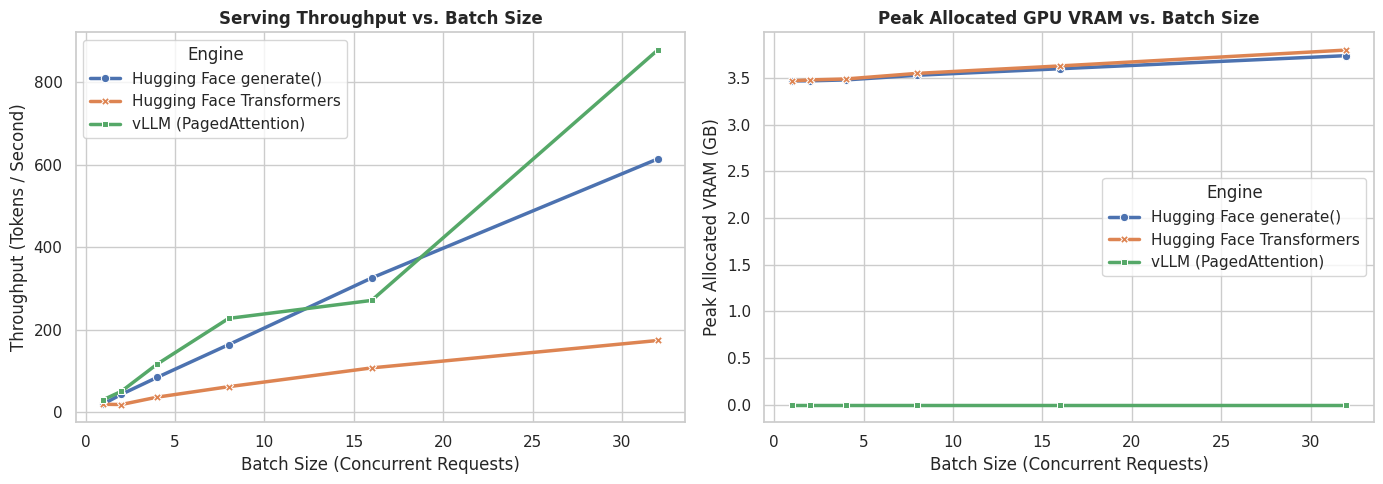

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Kaggle HF baseline and Colab vLLM results
df_hf = pd.read_csv("benchmark_results.csv")
# Keep only Hugging Face rows from Kaggle results
df_hf = df_hf[df_hf["Engine"].str.contains("Hugging Face")]

df_vllm = pd.read_csv("vllm_results.csv")

# Combine into master DataFrame
df_master = pd.concat([df_hf, df_vllm], ignore_index=True)
df_master.to_csv("final_vllm_vs_hf_benchmark.csv", index=False)

# Plot Comparison Graphs
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Throughput Plot
sns.lineplot(
    data=df_master, x="Batch Size", y="Throughput (tok/s)",
    hue="Engine", style="Engine", markers=True, dashes=False, linewidth=2.5, ax=axes[0]
)
axes[0].set_title("Serving Throughput vs. Batch Size", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Batch Size (Concurrent Requests)")
axes[0].set_ylabel("Throughput (Tokens / Second)")

# VRAM Plot
sns.lineplot(
    data=df_master, x="Batch Size", y="Peak Allocated VRAM (GB)",
    hue="Engine", style="Engine", markers=True, dashes=False, linewidth=2.5, ax=axes[1]
)
axes[1].set_title("Peak Allocated GPU VRAM vs. Batch Size", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Batch Size (Concurrent Requests)")
axes[1].set_ylabel("Peak Allocated VRAM (GB)")

plt.tight_layout()
plt.savefig("vllm_vs_hf_final_comparison.png", dpi=300)
plt.show()